### T/S/PON/DO anomalies: WINTER (DJF) - SPRING (MAM) - SUMMER (JJA) - FALL (SON)

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

#import plotly
from IPython.display import display, HTML
#plotly.offline.init_notebook_mode()
display(HTML(
    '<script type="text/javascript" async src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.1/MathJax.js?config=TeX-MML-AM_SVG"></script>'
))
from scipy.stats import pearsonr

In [2]:
with xr.open_dataset('/home/sallen/MEOPAR/grid/mesh_mask202108.nc') as mesh:
    tmask = mesh.tmask
    mbathy = mesh.mbathy

In [3]:
#dir='/ocean/atall/MOAD/Model/month-avg.202410/2015_2020/'
dir='/ocean/atall/MOAD/Model/month-avg.202606/2015-2020/'
ds_chem= xr.open_mfdataset(f'{dir}SalishSeaCast_1m_chem_T_20*', concat_dim="month", combine="nested",
                data_vars='minimal', coords='minimal', compat='override', autoclose=True, parallel=True)
ds_chem_clim = ds_chem.groupby(ds_chem.month).mean(dim='month')
ds_biol= xr.open_mfdataset(f'{dir}SalishSeaCast_1m_biol_T_20*', concat_dim="month", combine="nested",
                data_vars='minimal', coords='minimal', compat='override', autoclose=True, parallel=True)
ds_biol_clim = ds_biol.groupby(ds_biol.month).mean(dim='month')
ds_grdT= xr.open_mfdataset(f'{dir}SalishSeaCast_1m_grid_T_20*', concat_dim="month", combine="nested",
                data_vars='minimal', coords='minimal', compat='override', autoclose=True, parallel=True)
ds_grdT_clim = ds_grdT.groupby(ds_grdT.month).mean(dim='month')

In [4]:
tmask2 = tmask.assign_coords(x=("x", ds_chem_clim.dissolved_oxygen.gridX.data), y=("y", ds_chem_clim.dissolved_oxygen.gridY.data), z=("z", ds_chem_clim.dissolved_oxygen.depth.data))
mbathy2 = mbathy.assign_coords(x=("x", ds_chem_clim.dissolved_oxygen.gridX.data), y=("y", ds_chem_clim.dissolved_oxygen.gridY.data))
tmask2 = tmask2.rename({"y": "gridY"})
tmask2 = tmask2.rename({"x": "gridX"})
tmask2 = tmask2.rename({"z": "depth"})
mbathy2=mbathy2.rename({"y": "gridY"})
mbathy2=mbathy2.rename({"x": "gridX"})


In [5]:
jj,ii=423,266 # Central node (SoG)

#### Interanual variability

at Central node


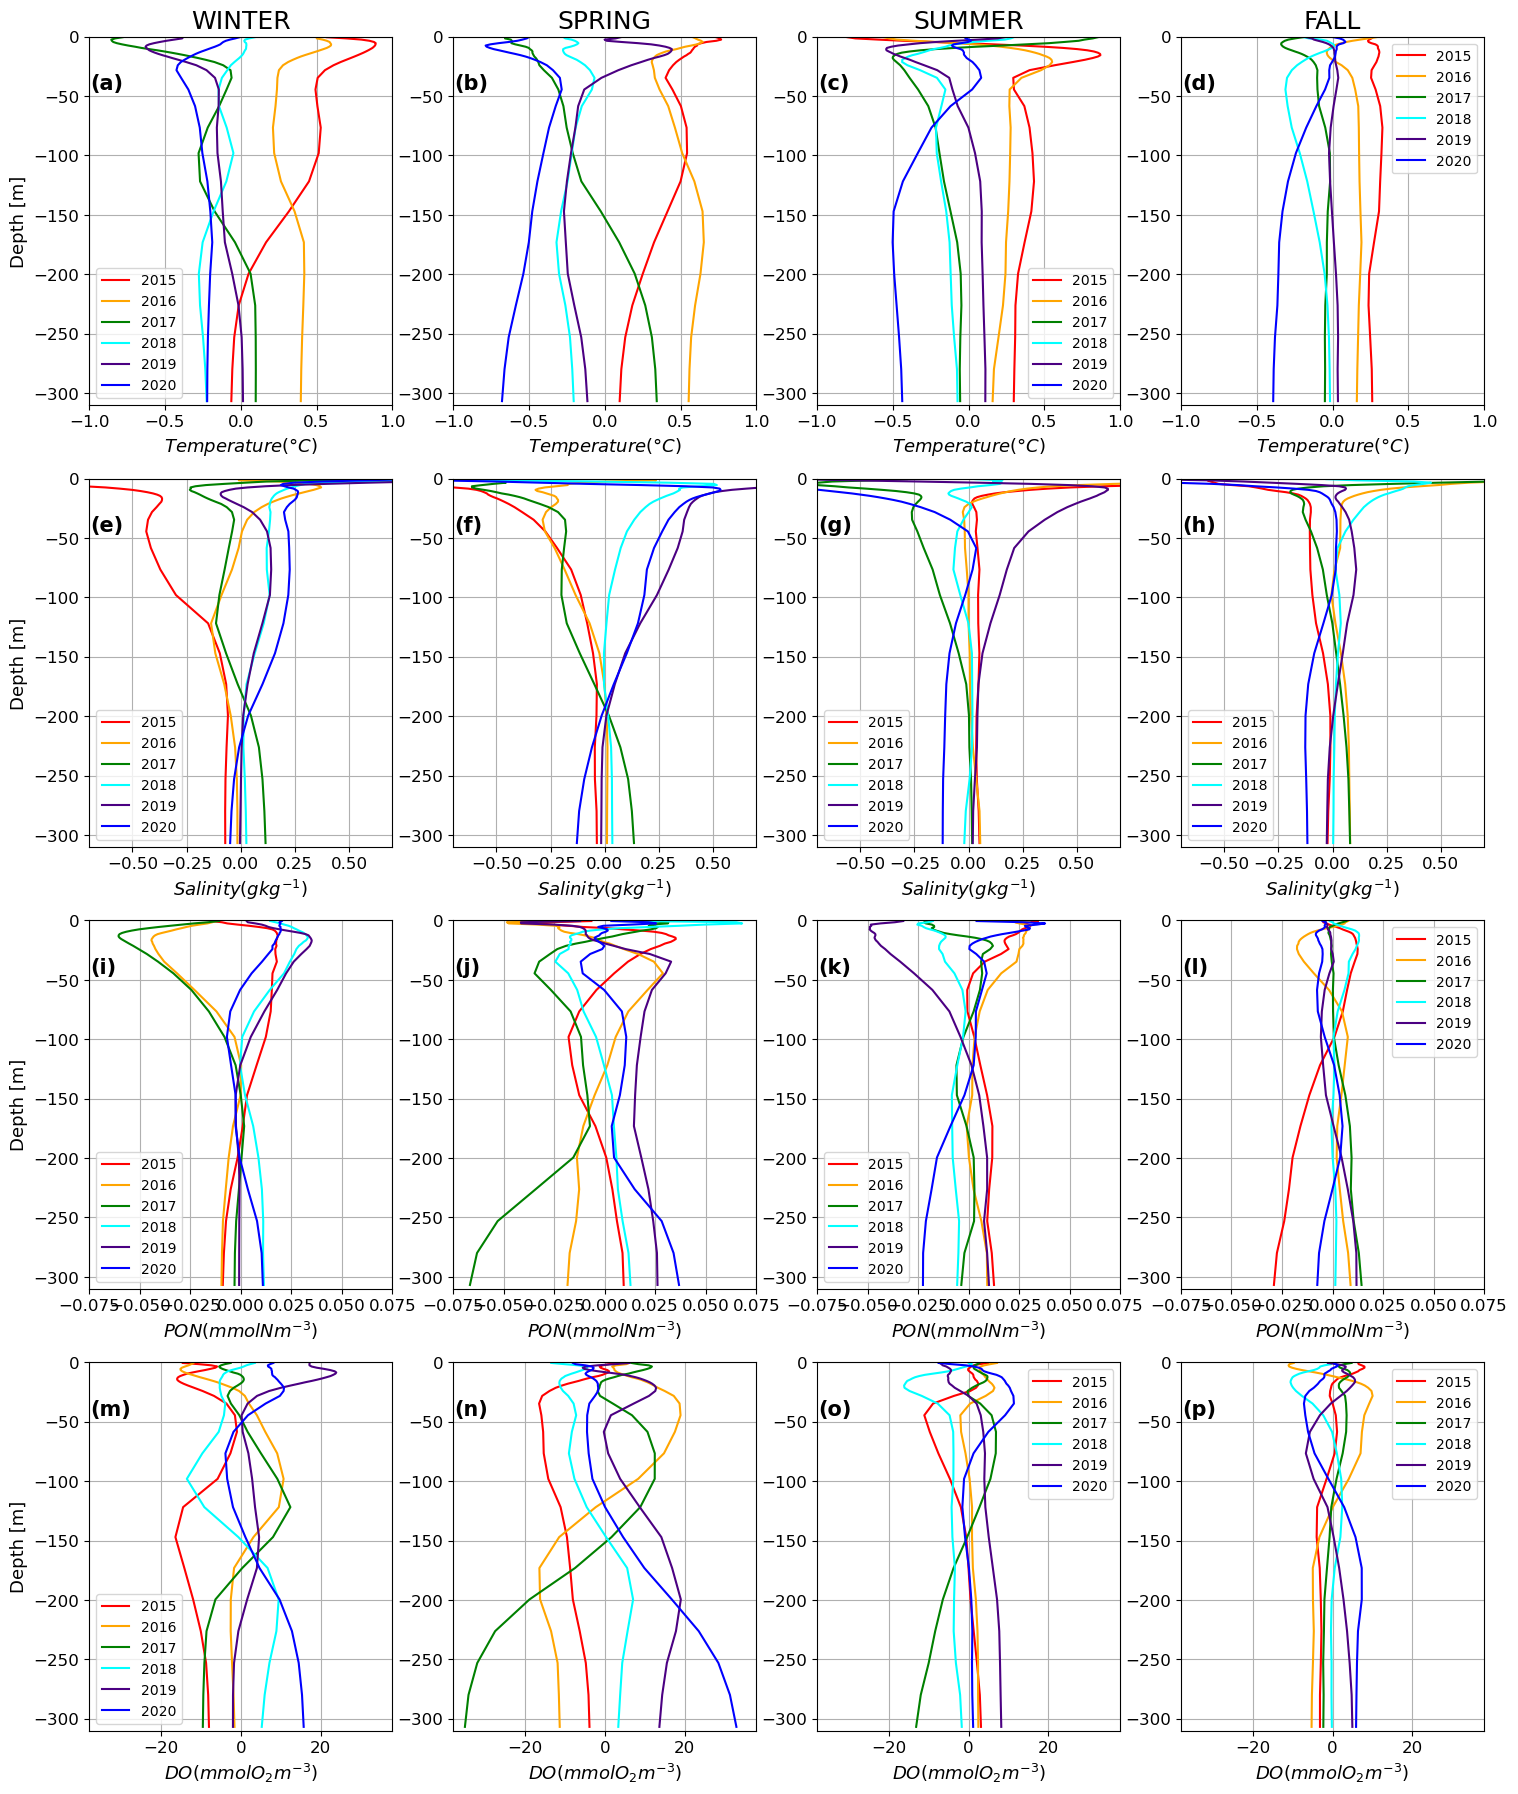

In [7]:
line, col, nyear = (4, 4, 6)
kk = np.array(np.max(mbathy2[0, jj, ii]))
fig, ax = plt.subplots(line, col, figsize=(18, 22))
colors = list(['red','orange','green','cyan','indigo','blue'])
for j in range(col):
    if j==0:
        ti,te=(0,3)
        title='WINTER'
    elif j==1:
        ti,te=(3,6)
        title='SPRING'
    elif j==2:
        ti,te=(6,9)
        title='SUMMER'
    else:
        ti,te=(9,12)
        title='FALL'
    for i in range (nyear):
        if i==0:
            year=2015
        else:
            year=year+1
        ds_chemY= xr.open_mfdataset(f'{dir}SalishSeaCast_1m_chem_T_{year-1}1201_{year}1130.nc')
        ds_grdTY= xr.open_mfdataset(f'{dir}SalishSeaCast_1m_grid_T_{year-1}1201_{year}1130.nc')
        ds_biolY= xr.open_mfdataset(f'{dir}SalishSeaCast_1m_biol_T_{year-1}1201_{year}1130.nc')
        sal=ds_grdTY.vosaline[:, :kk, jj, ii].where(tmask2[0, mbathy2[0, jj, ii]-1, jj, ii]==1)-ds_grdT_clim.vosaline[:, :kk, jj, ii].where(tmask2[0, mbathy2[0, jj, ii]-1, jj, ii]==1)
        sal = np.where(sal==0, np.nan, sal)
        tem=ds_grdTY.votemper[:, :kk, jj, ii].where(tmask2[0, mbathy2[0, jj, ii]-1, jj, ii]==1)-ds_grdT_clim.votemper[:, :kk, jj, ii].where(tmask2[0, mbathy2[0, jj, ii]-1, jj, ii]==1)
        tem = np.where(tem==0, np.nan, tem)
        oxy=ds_chemY.dissolved_oxygen[:, :kk, jj, ii].where(tmask2[0, mbathy2[0, jj, ii]-1, jj, ii]==1)-ds_chem_clim.dissolved_oxygen[:, :kk, jj, ii].where(tmask2[0, mbathy2[0, jj, ii]-1, jj, ii]==1)
        oxy = np.where(oxy==0, np.nan, oxy)
        pon=ds_biolY.particulate_organic_nitrogen[:, :kk, jj, ii].where(tmask2[0, mbathy2[0, jj, ii]-1, jj, ii]==1)-ds_biol_clim.particulate_organic_nitrogen[:, :kk, jj, ii].where(tmask2[0, mbathy2[0, jj, ii]-1, jj, ii]==1)
        pon = np.where(pon==0, np.nan, pon)
        labels=['$Temperature (°C)$','$Salinity (gkg^{-1})$','$PON (mmolNm^{-3})$','$DO (mmolO_2m^{-3})$']
        vars = [tem,sal,pon,oxy]
        lim = [1,0.7,0.075,38]
        for v in range(line):
            ax[v,j].plot(np.nanmean(vars[v][ti:te],axis=0),-ds_grdTY.depth[:kk], color=colors[i], label=year)
            ax[v,j].set_xlim(-lim[v],lim[v])
            ax[v,j].set_ylim(-310,0)
            ax[v,j].set_xlabel(f'{labels[v]}',fontsize=13)
            ax[v,0].set_ylabel('Depth [m]',fontsize=13)
            ax[0,j].set_title(f'{title}',fontsize=18)
            ax[v,j].tick_params(labelsize=12)
            ax[v,j].grid(True)
            if j==0 or j==2 or j==3:
                ax[v,j].legend()
letters = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)','(i)','(j)','(k)','(l)','(m)','(n)','(o)','(p)']
k = 0
for r in range(4):
    for c in range(4):
        ax[r,c].text(0.005,0.9,letters[k],transform=ax[r,c].transAxes,fontweight='bold',va='top',fontsize=15)
        k += 1
print('at Central node')
fig.savefig('/ocean/atall/MOAD/analysis-abdoul/figures/figsAnalysiSOG/TSDOPON_year-to-year_CN.png',dpi=300)

#### Anomalies below 250 m depth: working figs, not used in the paper

In [8]:
# Figure for annual anomalies at ~250m depth
line, col, nyear = (4, 4, 6)
kk = np.array(np.max(mbathy2[0, jj, ii]))
colors = list(['red','orange','green','cyan','indigo','blue'])

# Find the depth level closest to 250m
ds_grd = xr.open_mfdataset(f'{dir}SalishSeaCast_1m_grid_T_20151201_20161130.nc')
depth_levels = ds_grd.depth[:kk].values
target_depth = 250
depth_idx = np.argmin(np.abs(depth_levels - target_depth))
actual_depth = depth_levels[depth_idx]

print(f"Using depth level {depth_idx} corresponding to {actual_depth:.1f} m")

# Initialize lists to store annual means at ~250m depth
years_list = []
annual_tem_250m = []
annual_oxy_250m = []
annual_sal_250m = []
annual_pon_250m = []

for i in range(nyear):
    if i == 0:
        year = 2015
    else:
        year = year + 1
    
    # Open datasets for the current year
    ds_chemY = xr.open_mfdataset(f'{dir}SalishSeaCast_1m_chem_T_{year-1}1201_{year}1130.nc')
    ds_grdTY = xr.open_mfdataset(f'{dir}SalishSeaCast_1m_grid_T_{year-1}1201_{year}1130.nc')
    ds_biolY = xr.open_mfdataset(f'{dir}SalishSeaCast_1m_biol_T_{year-1}1201_{year}1130.nc')
    
    # Calculate anomalies (same as before)
    sal = ds_grdTY.vosaline[:, :kk, jj, ii].where(tmask2[0, mbathy2[0, jj, ii]-1, jj, ii]==1) - ds_grdT_clim.vosaline[:, :kk, jj, ii].where(tmask2[0, mbathy2[0, jj, ii]-1, jj, ii]==1)
    sal = np.where(sal==0, np.nan, sal)
    
    tem = ds_grdTY.votemper[:, :kk, jj, ii].where(tmask2[0, mbathy2[0, jj, ii]-1, jj, ii]==1) - ds_grdT_clim.votemper[:, :kk, jj, ii].where(tmask2[0, mbathy2[0, jj, ii]-1, jj, ii]==1)
    tem = np.where(tem==0, np.nan, tem)
    
    oxy = ds_chemY.dissolved_oxygen[:, :kk, jj, ii].where(tmask2[0, mbathy2[0, jj, ii]-1, jj, ii]==1) - ds_chem_clim.dissolved_oxygen[:, :kk, jj, ii].where(tmask2[0, mbathy2[0, jj, ii]-1, jj, ii]==1)
    oxy = np.where(oxy==0, np.nan, oxy)
    
    pon = ds_biolY.particulate_organic_nitrogen[:, :kk, jj, ii].where(tmask2[0, mbathy2[0, jj, ii]-1, jj, ii]==1) - ds_biol_clim.particulate_organic_nitrogen[:, :kk, jj, ii].where(tmask2[0, mbathy2[0, jj, ii]-1, jj, ii]==1)
    pon = np.where(pon==0, np.nan, pon)
    
    # Calculate annual mean anomaly at ~250m depth
    annual_tem_mean = np.nanmean(tem[:, depth_idx])
    annual_oxy_mean = np.nanmean(oxy[:, depth_idx])
    annual_sal_mean = np.nanmean(sal[:, depth_idx])
    annual_pon_mean = np.nanmean(pon[:, depth_idx])
    
    # Store results
    years_list.append(year)
    annual_tem_250m.append(annual_tem_mean)
    annual_oxy_250m.append(annual_oxy_mean)
    annual_sal_250m.append(annual_sal_mean)
    annual_pon_250m.append(annual_pon_mean)


Using depth level 32 corresponding to 253.1 m


Correlation between T and DO anomalies at 253.1 m: -0.720
Annual T and DO anomalies at ~253 m plotted at Central node


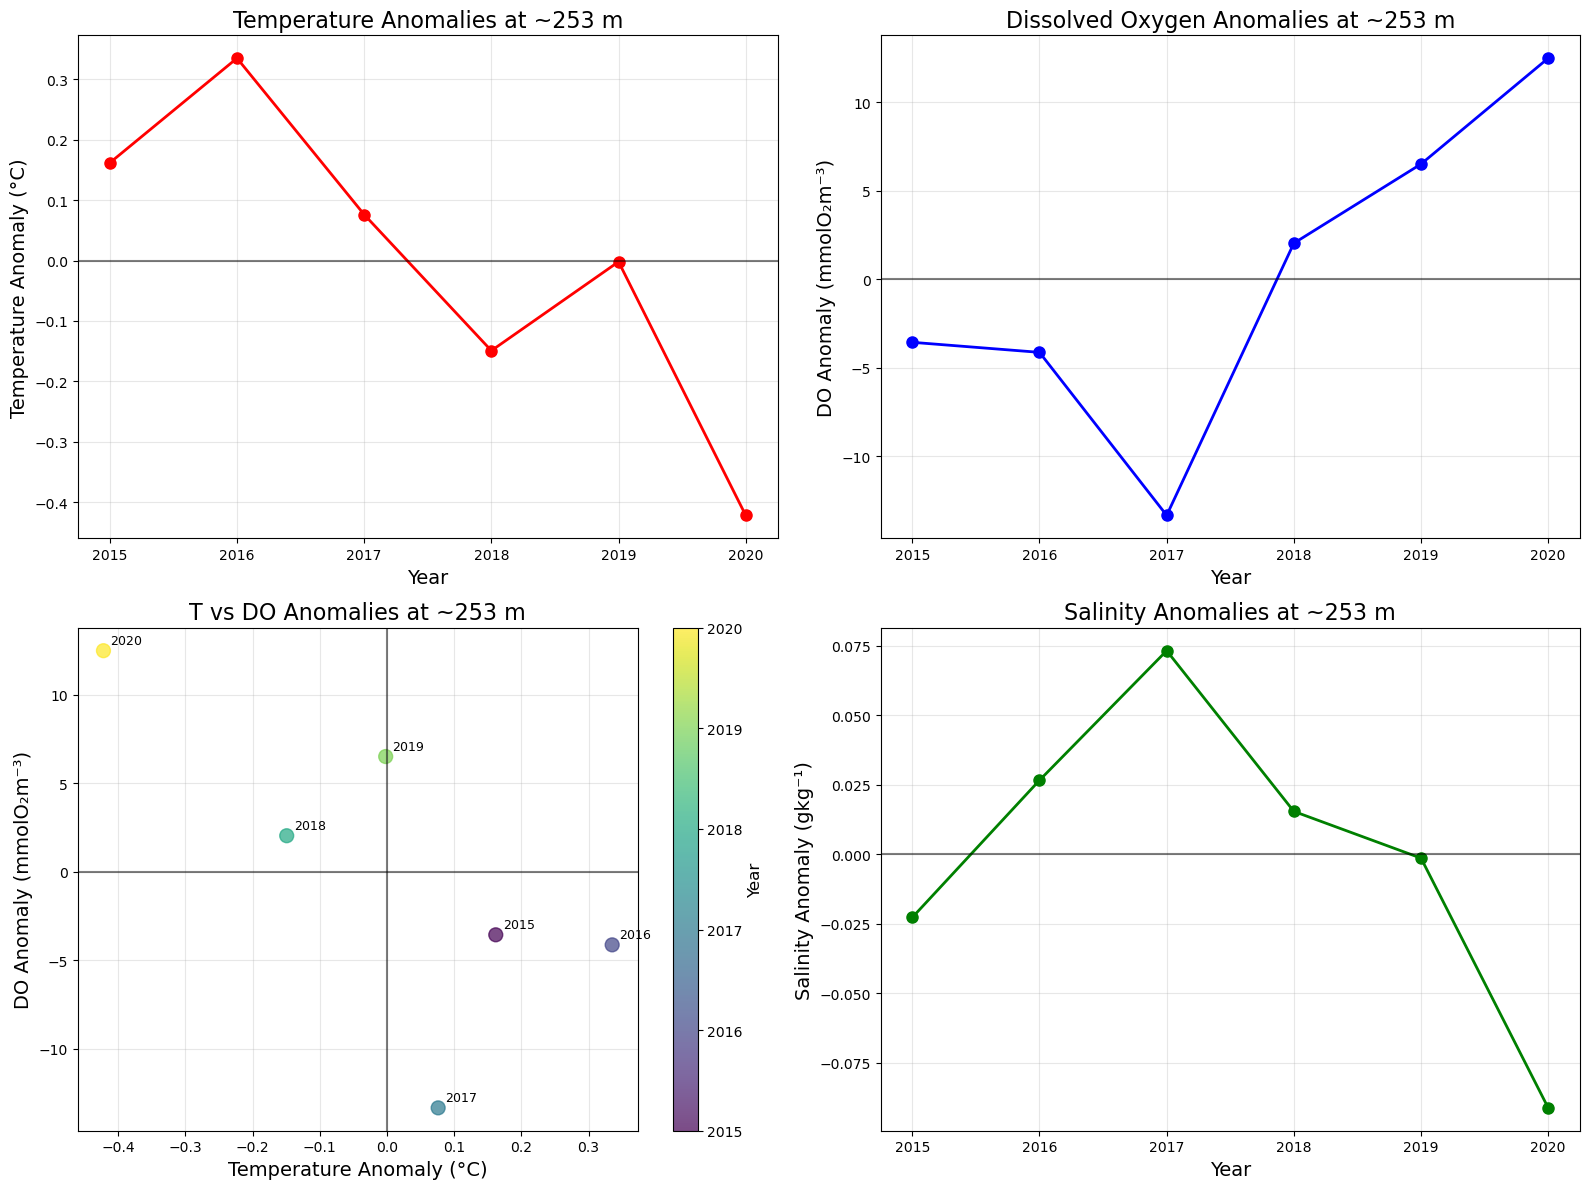

In [9]:
fig_annual, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
# Convert to numpy arrays
annual_tem_250m = np.array(annual_tem_250m)
annual_oxy_250m = np.array(annual_oxy_250m)
annual_sal_250m = np.array(annual_sal_250m)
annual_pon_250m = np.array(annual_pon_250m)

# Temperature anomalies
ax1.plot(years_list, annual_tem_250m, 'ro-', linewidth=2, markersize=8, markerfacecolor='red')
ax1.set_ylabel('Temperature Anomaly (°C)', fontsize=14)
ax1.set_xlabel('Year', fontsize=14)
ax1.set_title(f'Temperature Anomalies at ~{actual_depth:.0f} m', fontsize=16)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='k', linestyle='-', alpha=0.5)

# DO anomalies
ax2.plot(years_list, annual_oxy_250m, 'bo-', linewidth=2, markersize=8, markerfacecolor='blue')
ax2.set_ylabel('DO Anomaly (mmolO₂m⁻³)', fontsize=14)
ax2.set_xlabel('Year', fontsize=14)
ax2.set_title(f'Dissolved Oxygen Anomalies at ~{actual_depth:.0f} m', fontsize=16)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='k', linestyle='-', alpha=0.5)

# T vs DO anomalies
scatter = ax3.scatter(annual_tem_250m, annual_oxy_250m, c=years_list, cmap='viridis', s=100, alpha=0.7)
ax3.set_xlabel('Temperature Anomaly (°C)', fontsize=14)
ax3.set_ylabel('DO Anomaly (mmolO₂m⁻³)', fontsize=14)
ax3.set_title(f'T vs DO Anomalies at ~{actual_depth:.0f} m', fontsize=16)
ax3.grid(True, alpha=0.3)
ax3.axhline(y=0, color='k', linestyle='-', alpha=0.5)
ax3.axvline(x=0, color='k', linestyle='-', alpha=0.5)

# Add colorbar for years
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Year', fontsize=12)

for i, year in enumerate(years_list):
    ax3.annotate(str(year), (annual_tem_250m[i], annual_oxy_250m[i]),xytext=(5, 5), textcoords='offset points', fontsize=9)

# Salinity anomalies
ax4.plot(years_list, annual_sal_250m, 'go-', linewidth=2, markersize=8, markerfacecolor='green')
ax4.set_ylabel('Salinity Anomaly (gkg⁻¹)', fontsize=14)
ax4.set_xlabel('Year', fontsize=14)
ax4.set_title(f'Salinity Anomalies at ~{actual_depth:.0f} m', fontsize=16)
ax4.grid(True, alpha=0.3)
ax4.axhline(y=0, color='k', linestyle='-', alpha=0.5)

plt.tight_layout()

correlation = np.corrcoef(annual_tem_250m, annual_oxy_250m)[0,1]
print(f"Correlation between T and DO anomalies at {actual_depth:.1f} m: {correlation:.3f}")

fig_annual.savefig(f'/ocean/atall/MOAD/analysis-abdoul/figures/figsAnalysiSOG/Annual_T_S_DO_anomalies_250m_CN.png', dpi=300, bbox_inches='tight')

print(f'Annual T and DO anomalies at ~{actual_depth:.0f} m plotted at Central node')

In [10]:
# Define seasons
seasons = ['WINTER', 'SPRING', 'SUMMER', 'FALL']
season_months = [(0, 3), (3, 6), (6, 9), (9, 12)]  # (start_month, end_month)
colors = ['b', 'c', 'r', 'm']

# Initialize data structures
seasonal_data = {season: {'years': [], 'tem': [], 'oxy': [], 'sal': []} for season in seasons}

# Process data for each season and year
for i in range(nyear):
    if i == 0:
        year = 2015
    else:
        year = year + 1
    
    # Open datasets for the current year
    ds_chemY = xr.open_mfdataset(f'{dir}SalishSeaCast_1m_chem_T_{year-1}1201_{year}1130.nc')
    ds_grdTY = xr.open_mfdataset(f'{dir}SalishSeaCast_1m_grid_T_{year-1}1201_{year}1130.nc')
    ds_biolY = xr.open_mfdataset(f'{dir}SalishSeaCast_1m_biol_T_{year-1}1201_{year}1130.nc')
    
    # Calculate anomalies
    sal = ds_grdTY.vosaline[:, :kk, jj, ii].where(tmask2[0, mbathy2[0, jj, ii]-1, jj, ii]==1) - ds_grdT_clim.vosaline[:, :kk, jj, ii].where(tmask2[0, mbathy2[0, jj, ii]-1, jj, ii]==1)
    sal = np.where(sal==0, np.nan, sal)
    
    tem = ds_grdTY.votemper[:, :kk, jj, ii].where(tmask2[0, mbathy2[0, jj, ii]-1, jj, ii]==1) - ds_grdT_clim.votemper[:, :kk, jj, ii].where(tmask2[0, mbathy2[0, jj, ii]-1, jj, ii]==1)
    tem = np.where(tem==0, np.nan, tem)
    
    oxy = ds_chemY.dissolved_oxygen[:, :kk, jj, ii].where(tmask2[0, mbathy2[0, jj, ii]-1, jj, ii]==1) - ds_chem_clim.dissolved_oxygen[:, :kk, jj, ii].where(tmask2[0, mbathy2[0, jj, ii]-1, jj, ii]==1)
    oxy = np.where(oxy==0, np.nan, oxy)
    
    # Process each season
    for j, (season, (ti, te)) in enumerate(zip(seasons, season_months)):
        # Calculate seasonal mean anomaly at ~250m depth
        seasonal_tem = np.nanmean(tem[ti:te, depth_idx])
        seasonal_oxy = np.nanmean(oxy[ti:te, depth_idx])
        seasonal_sal = np.nanmean(sal[ti:te, depth_idx])
        
        # Store results
        seasonal_data[season]['years'].append(year)
        seasonal_data[season]['tem'].append(seasonal_tem)
        seasonal_data[season]['oxy'].append(seasonal_oxy)
        seasonal_data[season]['sal'].append(seasonal_sal)


##### Temperature & DO relationship below 250 m depth: only correlation coeff used

Seasonal T and DO analysis at ~253 m depth

Seasonal T-DO Correlation Summary
----------------------------------------------------------
Season        r        p-value      Significance
----------------------------------------------------------
WINTER     -0.575     0.2322         ns
SPRING     -0.852     0.0312         *
SUMMER     +0.293     0.5736         ns
FALL       -0.760     0.0797         ns


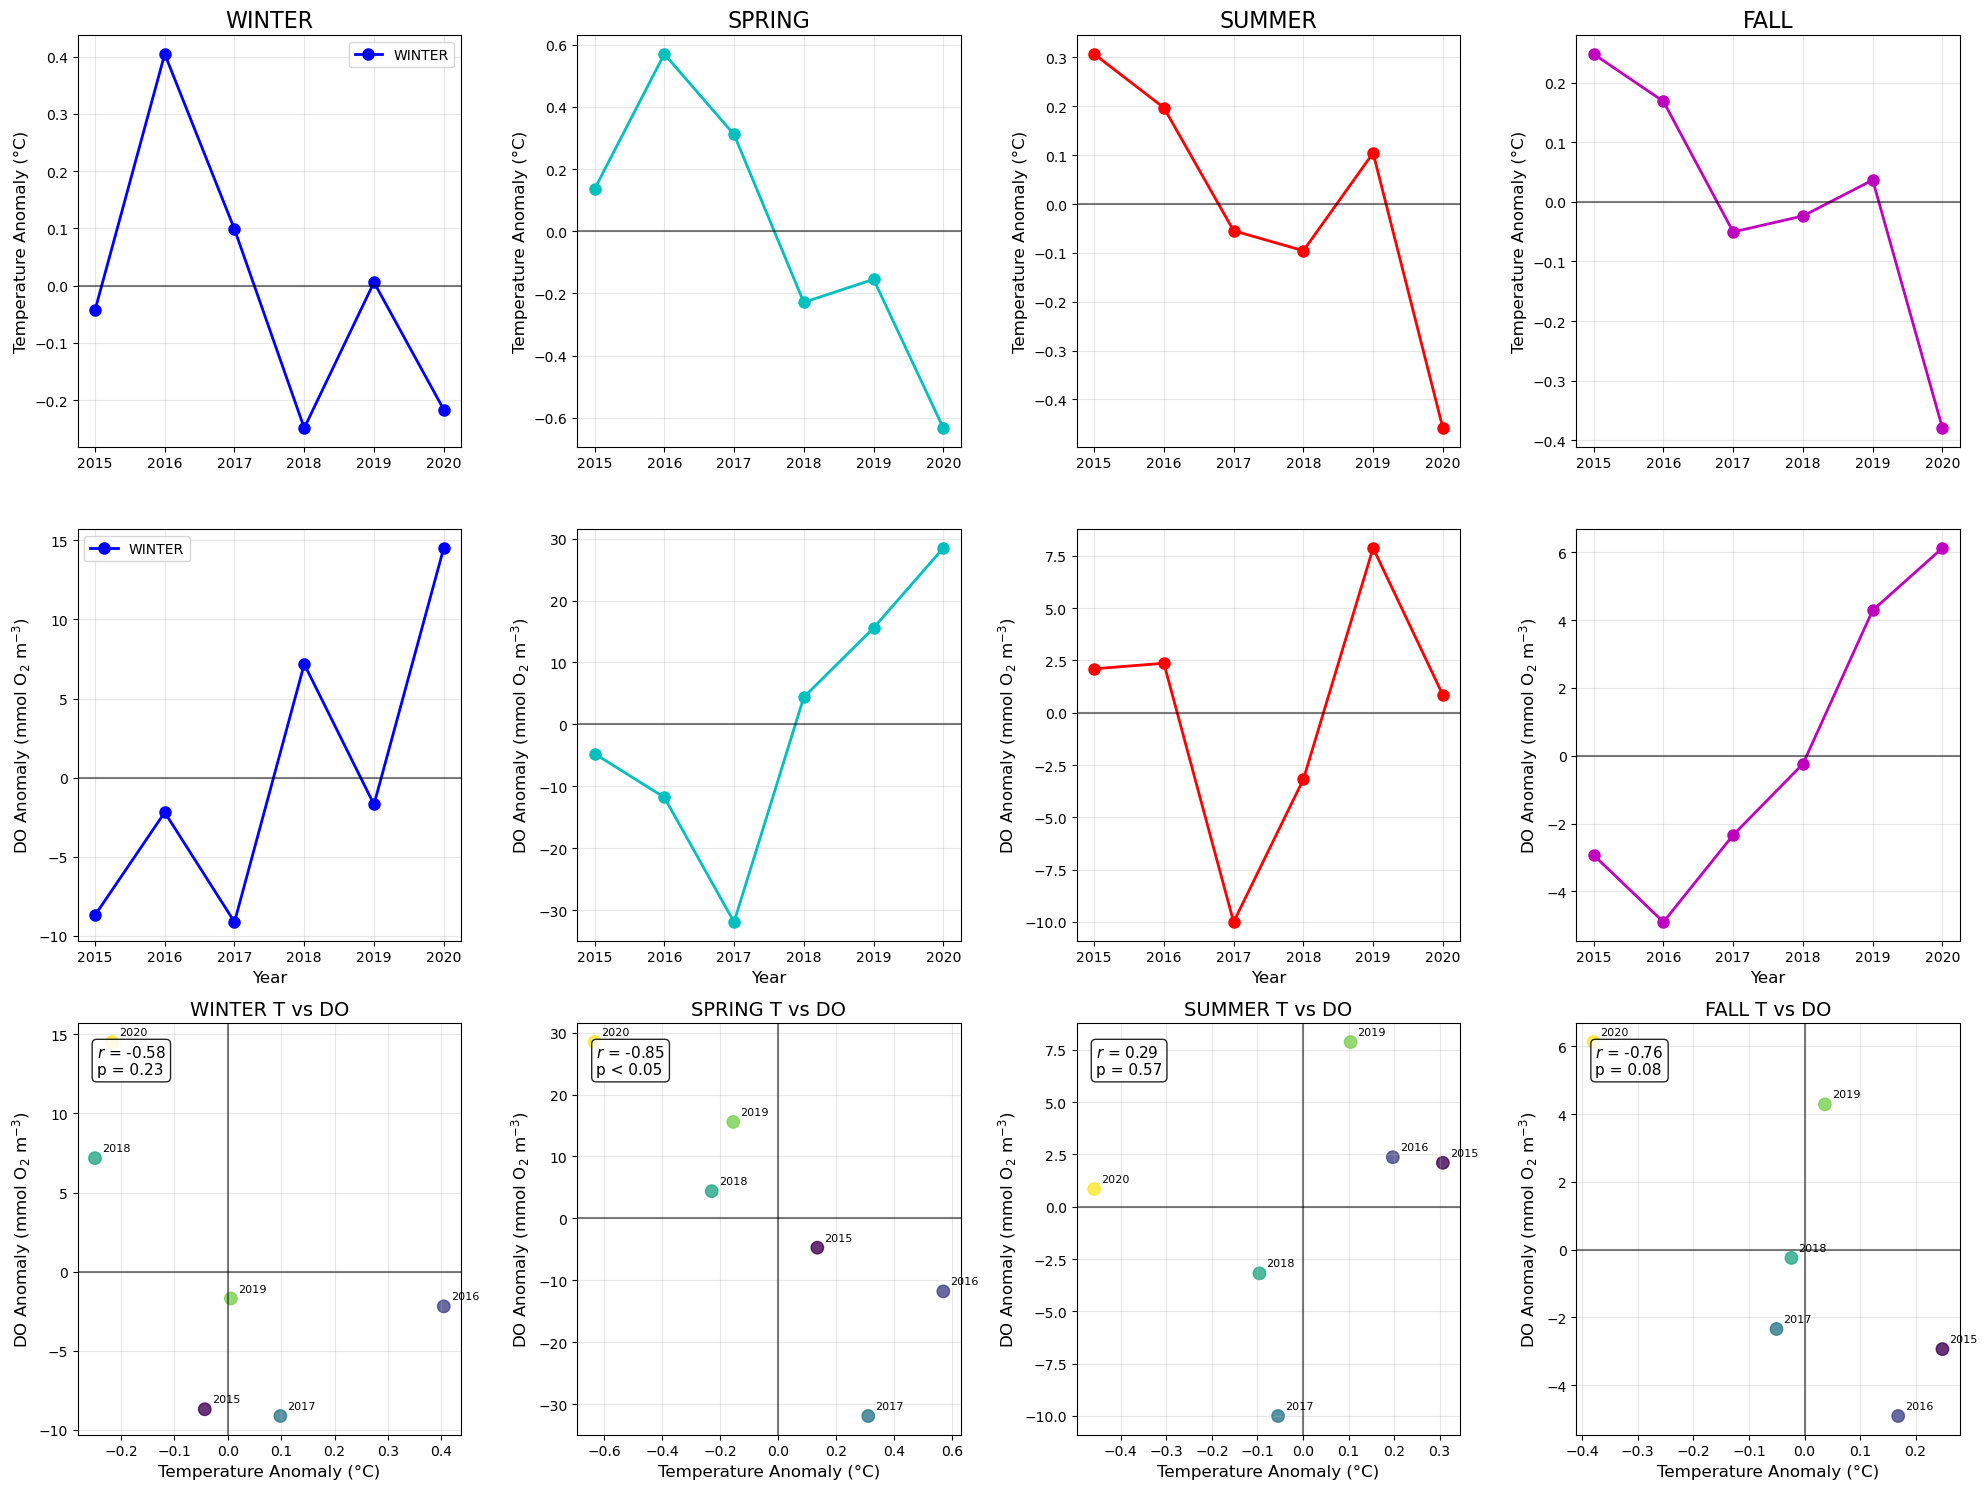

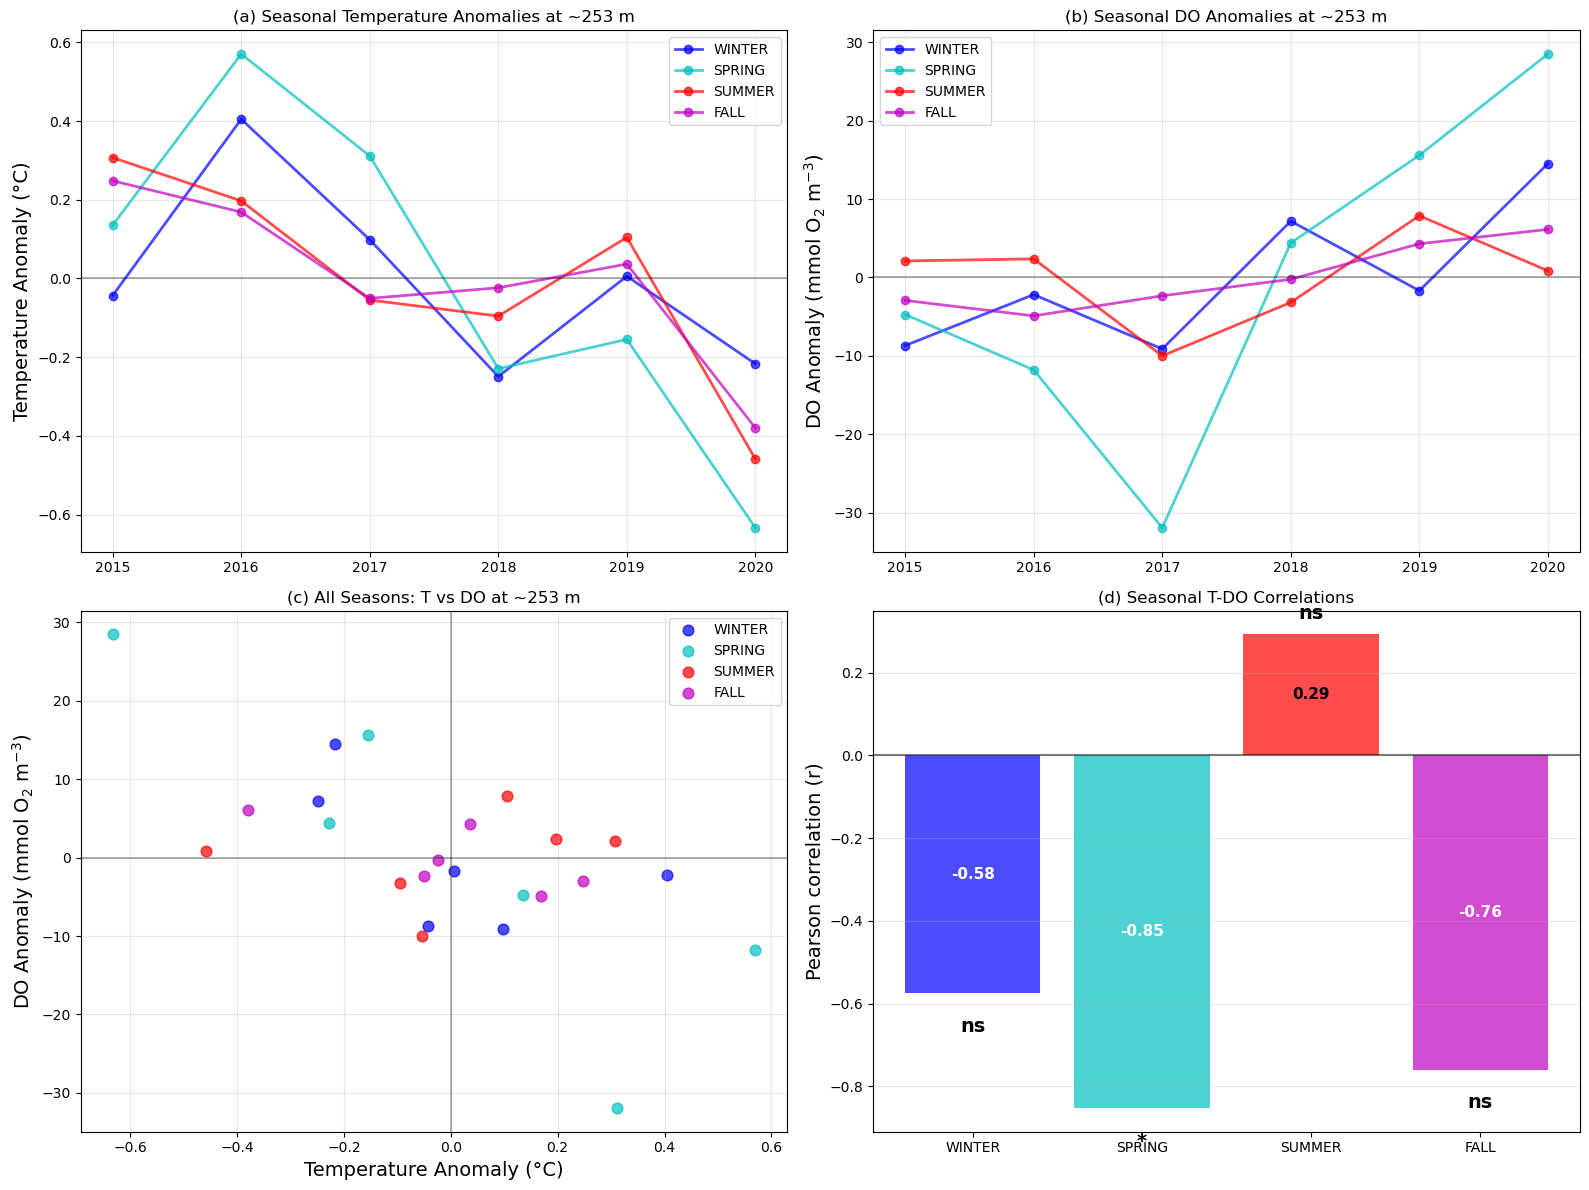

In [11]:
fig_seasonal, axes = plt.subplots(3, 4, figsize=(20, 15))

# Convert lists to numpy arrays
for season in seasons:
    for var in ['tem', 'oxy', 'sal']:
        seasonal_data[season][var] = np.array(seasonal_data[season][var])

# Temperature anomalies
for j, season in enumerate(seasons):

    axes[0, j].plot(seasonal_data[season]['years'],seasonal_data[season]['tem'],'o-',color=colors[j],linewidth=2,markersize=8,label=season)

    axes[0, j].set_title(season, fontsize=16)
    axes[0, j].set_ylabel('Temperature Anomaly (°C)', fontsize=12)
    axes[0, j].grid(True, alpha=0.3)
    axes[0, j].axhline(0, color='k', alpha=0.5)

    if j == 0:
        axes[0, j].legend()

# DO anomalies
for j, season in enumerate(seasons):

    axes[1, j].plot(seasonal_data[season]['years'],seasonal_data[season]['oxy'],'o-', color=colors[j],linewidth=2,markersize=8,label=season)

    axes[1, j].set_ylabel('DO Anomaly (mmol O$_2$ m$^{-3}$)', fontsize=12)
    axes[1, j].set_xlabel('Year', fontsize=12)
    axes[1, j].grid(True, alpha=0.3)
    axes[1, j].axhline(0, color='k', alpha=0.5)

    if j == 0:
        axes[1, j].legend()

# Temperature vs DO 
season_corrs = []
season_pvals = []

for j, season in enumerate(seasons):

    x = seasonal_data[season]['tem']
    y = seasonal_data[season]['oxy']

    # Pearson correlation
    r, p = pearsonr(x, y)

    season_corrs.append(r)
    season_pvals.append(p)

    scatter = axes[2, j].scatter(x,y,c=seasonal_data[season]['years'],cmap='viridis',s=80,alpha=0.8)

    axes[2, j].set_xlabel('Temperature Anomaly (°C)', fontsize=12)
    axes[2, j].set_ylabel('DO Anomaly (mmol O$_2$ m$^{-3}$)', fontsize=12)
    axes[2, j].set_title(f'{season} T vs DO', fontsize=14)

    axes[2, j].grid(True, alpha=0.3)
    axes[2, j].axhline(0, color='k', alpha=0.5)
    axes[2, j].axvline(0, color='k', alpha=0.5)

    # Add year labels
    for idx, year in enumerate(seasonal_data[season]['years']):
        axes[2, j].annotate(str(year),(x[idx], y[idx]),xytext=(5,5),textcoords='offset points',fontsize=8)

    # Significance text
    if p < 0.001:
        ptxt = "p < 0.001"
    elif p < 0.01:
        ptxt = "p < 0.01"
    elif p < 0.05:
        ptxt = "p < 0.05"
    else:
        ptxt = f"p = {p:.2f}"

    axes[2, j].text(0.05,0.95,f"$r$ = {r:.2f}\n{ptxt}",transform=axes[2, j].transAxes,fontsize=11,verticalalignment='top',
        bbox=dict(boxstyle='round',facecolor='white',alpha=0.85)
        )

plt.tight_layout()

fig_seasonal.savefig(f'/ocean/atall/MOAD/analysis-abdoul/figures/figsAnalysiSOG/Seasonal_T_DO_analysis_250m_CN.png',dpi=300,bbox_inches='tight')

print(f'Seasonal T and DO analysis at ~{actual_depth:.0f} m depth')


# Print correlation summary
print("\nSeasonal T-DO Correlation Summary")
print("----------------------------------------------------------")
print("Season        r        p-value      Significance")
print("----------------------------------------------------------")

for season, r, p in zip(seasons, season_corrs, season_pvals):

    if p < 0.001:
        sig = "***"
    elif p < 0.01:
        sig = "**"
    elif p < 0.05:
        sig = "*"
    else:
        sig = "ns"

    print(f"{season:10} {r:+.3f}     {p:.4f}         {sig}")

# Combined seasonal figure
fig_combined, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2,figsize=(16,12))

# Temperature
for j, season in enumerate(seasons):
    ax1.plot(seasonal_data[season]['years'],seasonal_data[season]['tem'],'o-',color=colors[j],linewidth=2,markersize=6,alpha=0.7,label=season)

ax1.set_ylabel('Temperature Anomaly (°C)', fontsize=14)
ax1.set_title(f'(a) Seasonal Temperature Anomalies at ~{actual_depth:.0f} m')
ax1.grid(alpha=0.3)
ax1.legend()
ax1.axhline(0, color='k', alpha=0.3)

# DO
for j, season in enumerate(seasons):
    ax2.plot(seasonal_data[season]['years'],seasonal_data[season]['oxy'],'o-',color=colors[j],linewidth=2,markersize=6,alpha=0.7,label=season)

ax2.set_ylabel('DO Anomaly (mmol O$_2$ m$^{-3}$)', fontsize=14)
ax2.set_title(f'(b) Seasonal DO Anomalies at ~{actual_depth:.0f} m')
ax2.grid(alpha=0.3)
ax2.legend()
ax2.axhline(0, color='k', alpha=0.3)

# Scatter
for j, season in enumerate(seasons):

    ax3.scatter(seasonal_data[season]['tem'],seasonal_data[season]['oxy'],color=colors[j],s=60,alpha=0.7,label=season)

ax3.set_xlabel('Temperature Anomaly (°C)', fontsize=14)
ax3.set_ylabel('DO Anomaly (mmol O$_2$ m$^{-3}$)', fontsize=14)
ax3.set_title(f'(c) All Seasons: T vs DO at ~{actual_depth:.0f} m')
ax3.grid(alpha=0.3)
ax3.axhline(0, color='k', alpha=0.3)
ax3.axvline(0, color='k', alpha=0.3)
ax3.legend()

# Correlation bars
bars = ax4.bar(seasons,season_corrs,color=colors,alpha=0.7)

ax4.set_ylabel('Pearson correlation (r)', fontsize=14)
ax4.set_title('(d) Seasonal T-DO Correlations')
ax4.grid(alpha=0.3, axis='y')
ax4.axhline(0, color='k', alpha=0.5)

for bar, r, p in zip(bars, season_corrs, season_pvals):

    if p < 0.001:
        sig = "***"
    elif p < 0.01:
        sig = "**"
    elif p < 0.05:
        sig = "*"
    else:
        sig = "ns"

    height = bar.get_height()

    ax4.text(bar.get_x() + bar.get_width()/2,height/2,f"{r:.2f}",ha='center',va='center',fontsize=11,fontweight='bold',
             color='white' if abs(height) > 0.4 else 'black'
             )

    offset = 0.05 if height >= 0 else -0.08

    ax4.text(bar.get_x() + bar.get_width()/2,height + offset,sig,ha='center',va='center',fontsize=14,fontweight='bold')

plt.tight_layout()

fig_combined.savefig(f'/ocean/atall/MOAD/analysis-abdoul/figures/figsAnalysiSOG/Combined_TDOseasonal_analysis_250m_CN.png',dpi=300,bbox_inches='tight')

##### Salinity & DO relationship below 250 m depth: only correlation coeff used

Seasonal S and DO analysis at ~253 m depth

Seasonal S-DO Correlation Summary
----------------------------------------------------------
Season        r        p-value      Significance
----------------------------------------------------------
WINTER     -0.216     0.6815         ns
SPRING     -0.834     0.0391         *
SUMMER     +0.093     0.8615         ns
FALL       -0.851     0.0317         *


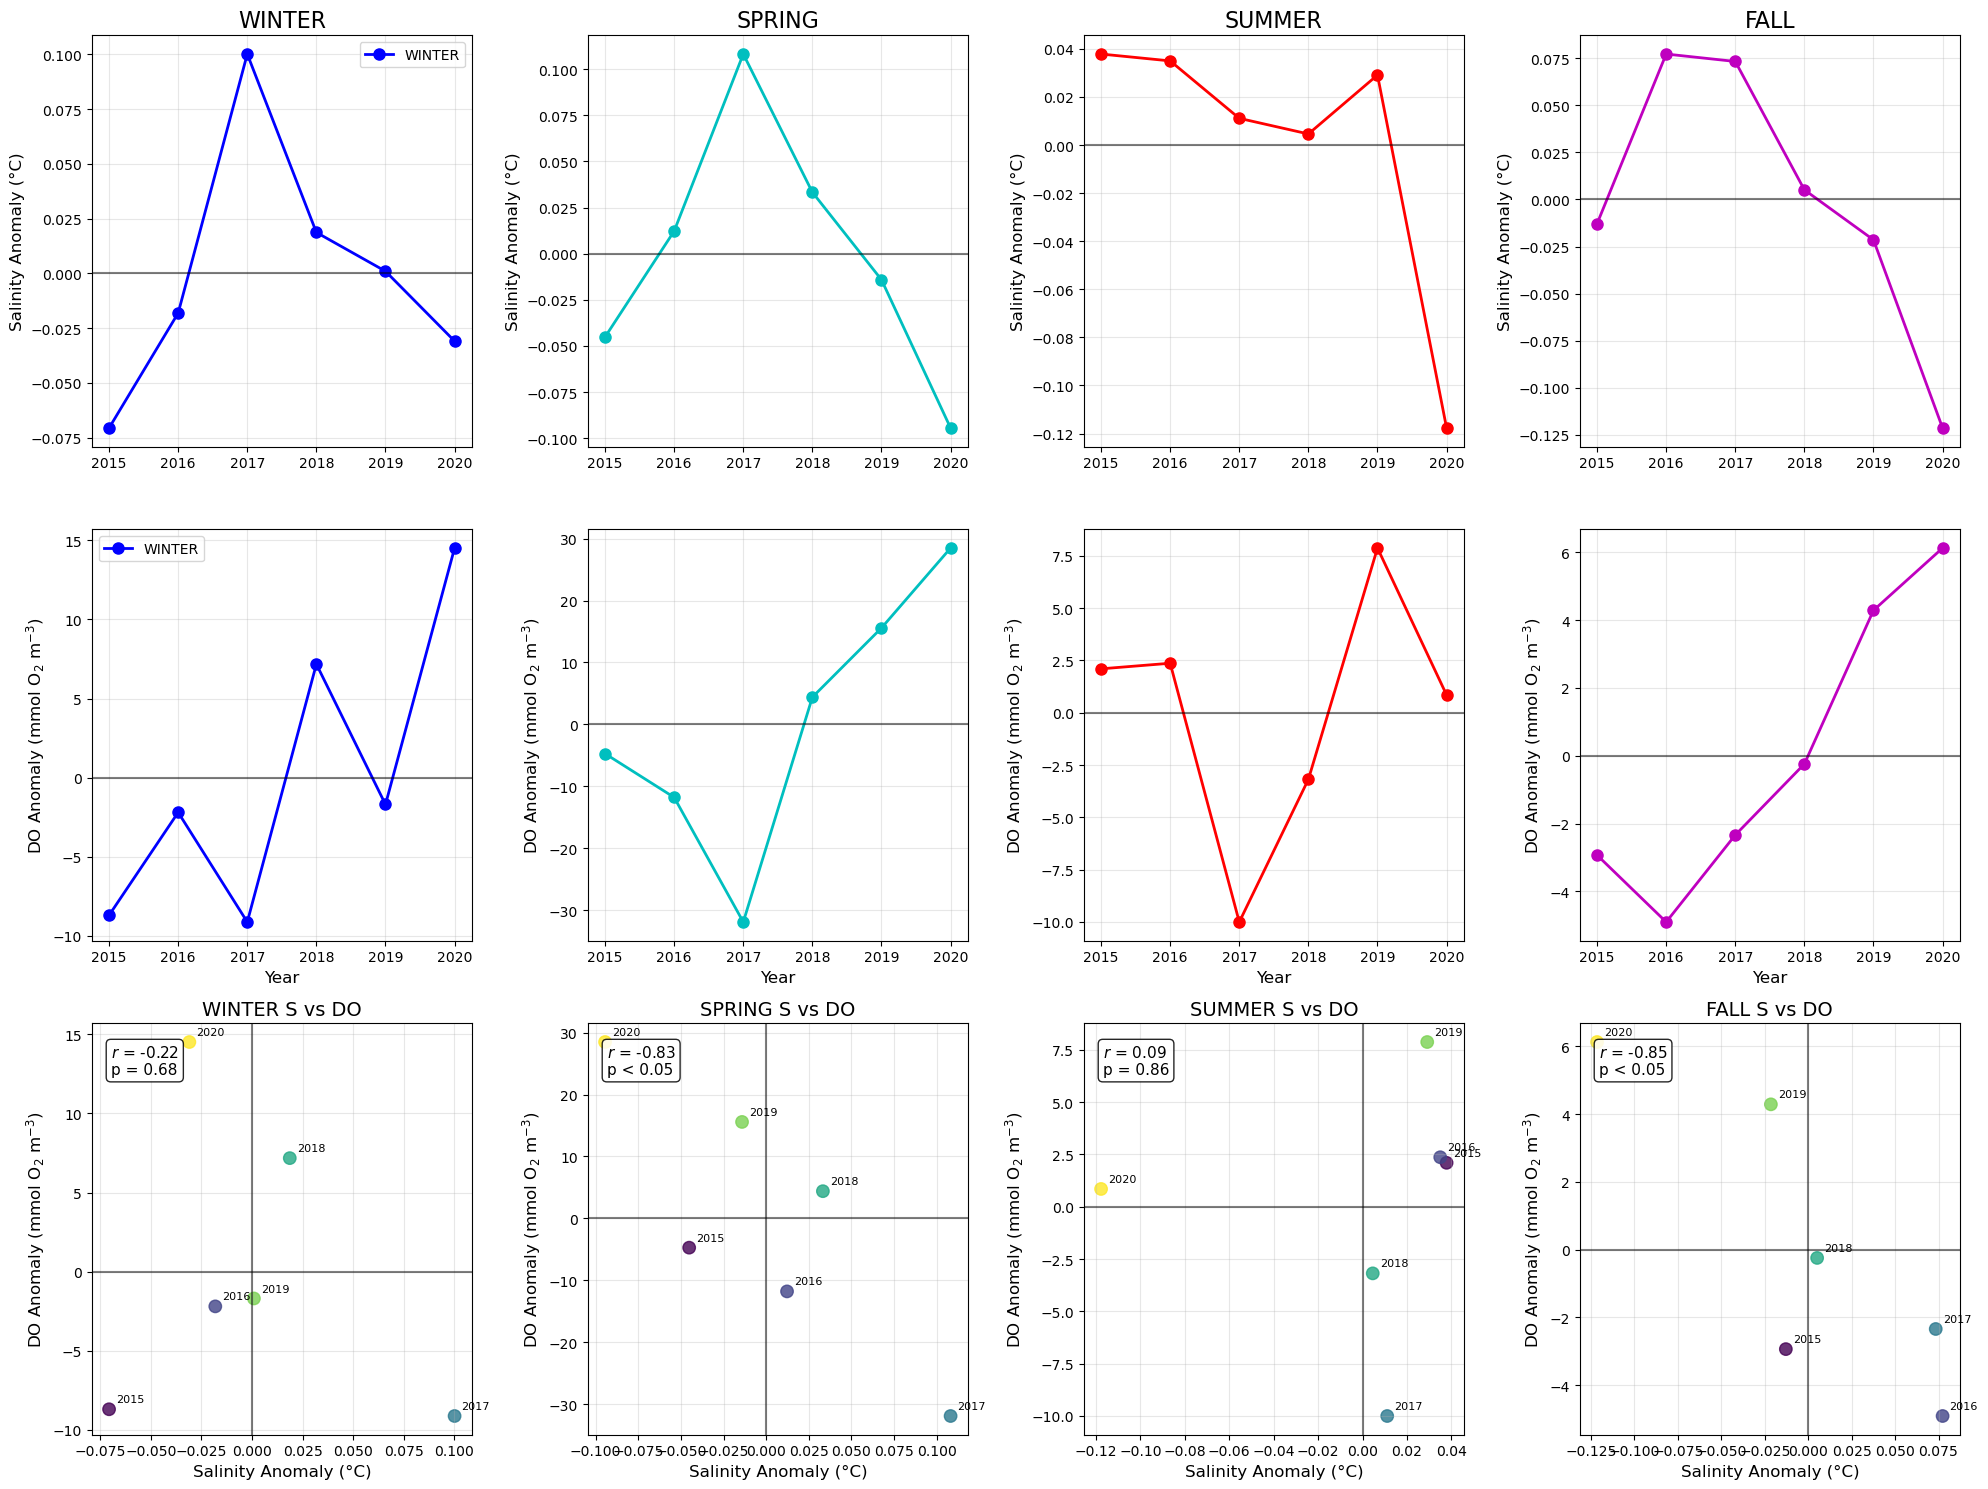

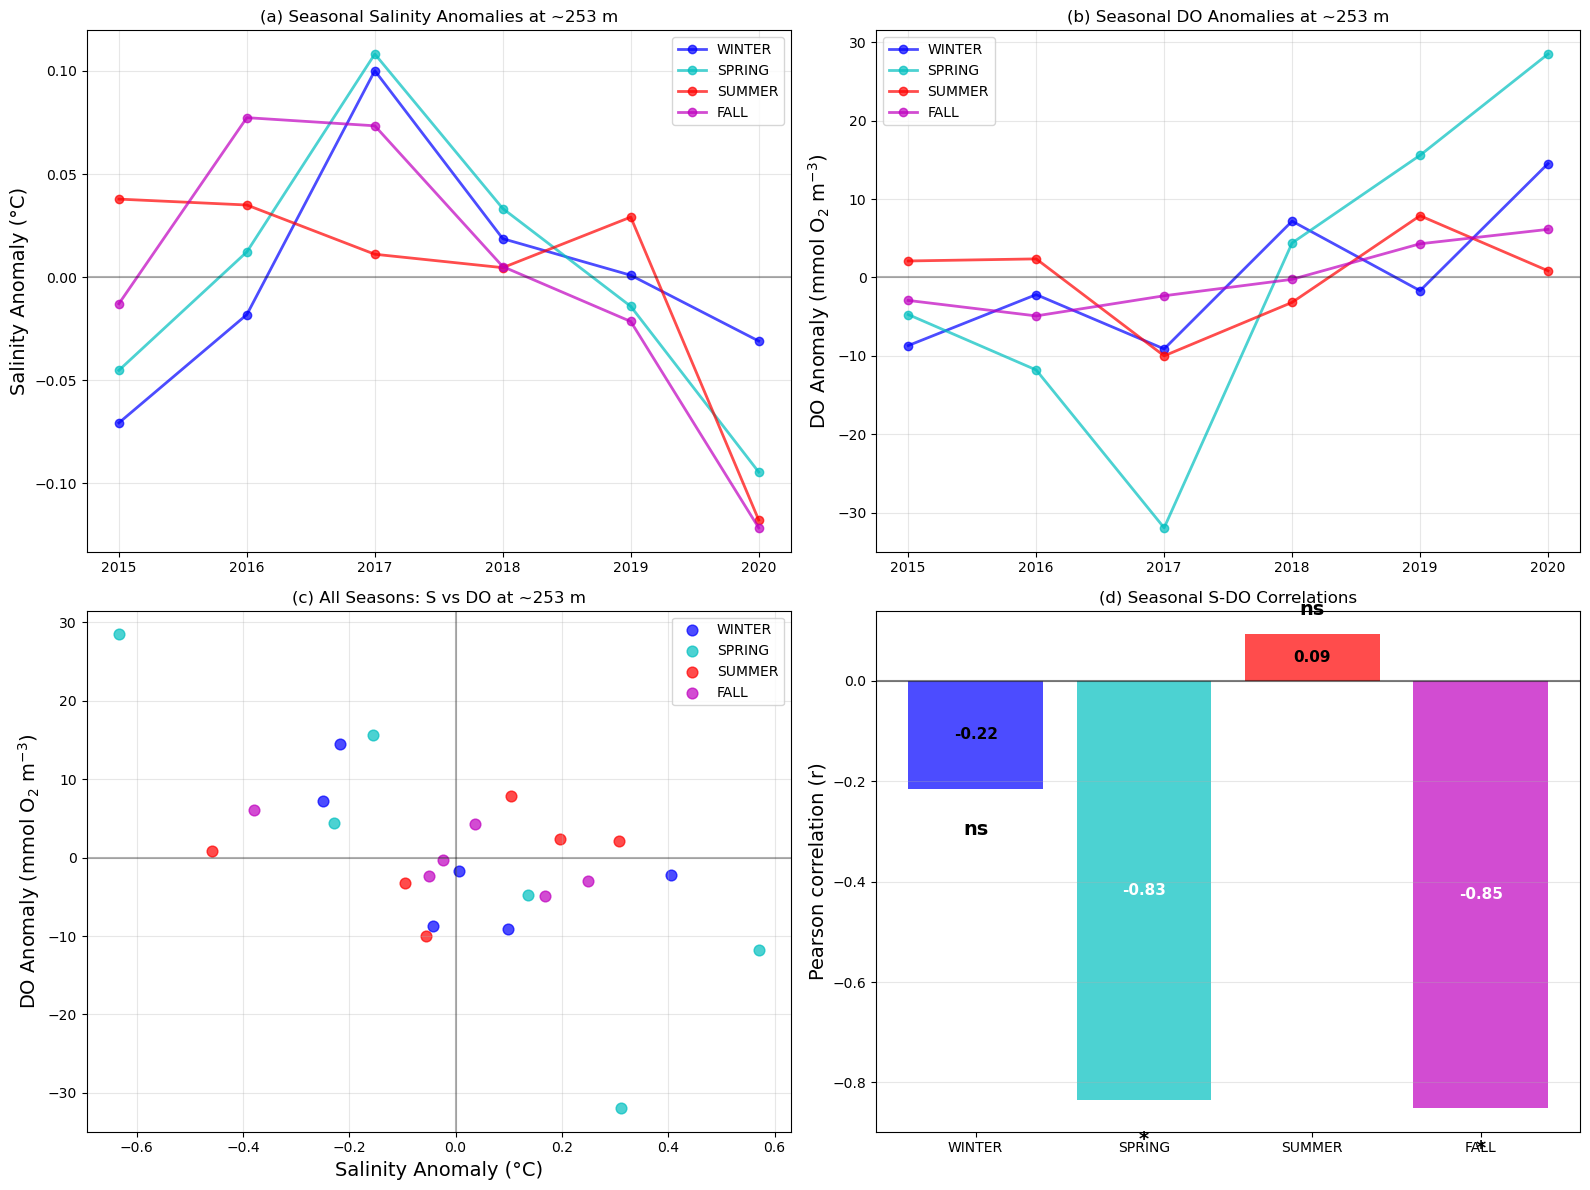

In [12]:
fig_seasonal, axes = plt.subplots(3, 4, figsize=(20, 15))

# Convert lists to numpy arrays
for season in seasons:
    for var in ['tem', 'oxy', 'sal']:
        seasonal_data[season][var] = np.array(seasonal_data[season][var])

# Temperature anomalies
for j, season in enumerate(seasons):
    axes[0, j].plot(seasonal_data[season]['years'],seasonal_data[season]['sal'],'o-',color=colors[j],linewidth=2,markersize=8,label=season)

    axes[0, j].set_title(season, fontsize=16)
    axes[0, j].set_ylabel('Salinity Anomaly (°C)', fontsize=12)
    axes[0, j].grid(True, alpha=0.3)
    axes[0, j].axhline(0, color='k', alpha=0.5)

    if j == 0:
        axes[0, j].legend()

# DO anomalies
for j, season in enumerate(seasons):

    axes[1, j].plot(seasonal_data[season]['years'],seasonal_data[season]['oxy'],'o-', color=colors[j],linewidth=2,markersize=8,label=season)

    axes[1, j].set_ylabel('DO Anomaly (mmol O$_2$ m$^{-3}$)', fontsize=12)
    axes[1, j].set_xlabel('Year', fontsize=12)
    axes[1, j].grid(True, alpha=0.3)
    axes[1, j].axhline(0, color='k', alpha=0.5)

    if j == 0:
        axes[1, j].legend()

# Salinity vs DO 
season_corrs = []
season_pvals = []

for j, season in enumerate(seasons):

    x = seasonal_data[season]['sal']
    y = seasonal_data[season]['oxy']

    # Pearson correlation
    r, p = pearsonr(x, y)

    season_corrs.append(r)
    season_pvals.append(p)

    scatter = axes[2, j].scatter(x,y,c=seasonal_data[season]['years'],cmap='viridis',s=80,alpha=0.8)

    axes[2, j].set_xlabel('Salinity Anomaly (°C)', fontsize=12)
    axes[2, j].set_ylabel('DO Anomaly (mmol O$_2$ m$^{-3}$)', fontsize=12)
    axes[2, j].set_title(f'{season} S vs DO', fontsize=14)

    axes[2, j].grid(True, alpha=0.3)
    axes[2, j].axhline(0, color='k', alpha=0.5)
    axes[2, j].axvline(0, color='k', alpha=0.5)

    # Add year labels
    for idx, year in enumerate(seasonal_data[season]['years']):
        axes[2, j].annotate(str(year),(x[idx], y[idx]),xytext=(5,5),textcoords='offset points',fontsize=8)

    # Significance text
    if p < 0.001:
        ptxt = "p < 0.001"
    elif p < 0.01:
        ptxt = "p < 0.01"
    elif p < 0.05:
        ptxt = "p < 0.05"
    else:
        ptxt = f"p = {p:.2f}"

    axes[2, j].text(0.05,0.95,f"$r$ = {r:.2f}\n{ptxt}",transform=axes[2, j].transAxes,fontsize=11,verticalalignment='top',
        bbox=dict(boxstyle='round',facecolor='white',alpha=0.85)
        )

plt.tight_layout()

fig_seasonal.savefig(f'/ocean/atall/MOAD/analysis-abdoul/figures/figsAnalysiSOG/Seasonal_S_DO_analysis_250m_CN.png',dpi=300,bbox_inches='tight')

print(f'Seasonal S and DO analysis at ~{actual_depth:.0f} m depth')


# Print correlation summary
print("\nSeasonal S-DO Correlation Summary")
print("----------------------------------------------------------")
print("Season        r        p-value      Significance")
print("----------------------------------------------------------")

for season, r, p in zip(seasons, season_corrs, season_pvals):

    if p < 0.001:
        sig = "***"
    elif p < 0.01:
        sig = "**"
    elif p < 0.05:
        sig = "*"
    else:
        sig = "ns"

    print(f"{season:10} {r:+.3f}     {p:.4f}         {sig}")

# Combined seasonal figure
fig_combined, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2,figsize=(16,12))

# Salinity
for j, season in enumerate(seasons):
    ax1.plot(seasonal_data[season]['years'],seasonal_data[season]['sal'],'o-',color=colors[j],linewidth=2,markersize=6,alpha=0.7,label=season)

ax1.set_ylabel('Salinity Anomaly (°C)', fontsize=14)
ax1.set_title(f'(a) Seasonal Salinity Anomalies at ~{actual_depth:.0f} m')
ax1.grid(alpha=0.3)
ax1.legend()
ax1.axhline(0, color='k', alpha=0.3)

# DO
for j, season in enumerate(seasons):
    ax2.plot(seasonal_data[season]['years'],seasonal_data[season]['oxy'],'o-',color=colors[j],linewidth=2,markersize=6,alpha=0.7,label=season)

ax2.set_ylabel('DO Anomaly (mmol O$_2$ m$^{-3}$)', fontsize=14)
ax2.set_title(f'(b) Seasonal DO Anomalies at ~{actual_depth:.0f} m')
ax2.grid(alpha=0.3)
ax2.legend()
ax2.axhline(0, color='k', alpha=0.3)

# Scatter
for j, season in enumerate(seasons):

    ax3.scatter(seasonal_data[season]['tem'],seasonal_data[season]['oxy'],color=colors[j],s=60,alpha=0.7,label=season)

ax3.set_xlabel('Salinity Anomaly (°C)', fontsize=14)
ax3.set_ylabel('DO Anomaly (mmol O$_2$ m$^{-3}$)', fontsize=14)
ax3.set_title(f'(c) All Seasons: S vs DO at ~{actual_depth:.0f} m')
ax3.grid(alpha=0.3)
ax3.axhline(0, color='k', alpha=0.3)
ax3.axvline(0, color='k', alpha=0.3)
ax3.legend()

# Correlation bars
bars = ax4.bar(seasons,season_corrs,color=colors,alpha=0.7)

ax4.set_ylabel('Pearson correlation (r)', fontsize=14)
ax4.set_title('(d) Seasonal S-DO Correlations')
ax4.grid(alpha=0.3, axis='y')
ax4.axhline(0, color='k', alpha=0.5)

for bar, r, p in zip(bars, season_corrs, season_pvals):

    if p < 0.001:
        sig = "***"
    elif p < 0.01:
        sig = "**"
    elif p < 0.05:
        sig = "*"
    else:
        sig = "ns"

    height = bar.get_height()

    ax4.text(bar.get_x() + bar.get_width()/2,height/2,f"{r:.2f}",ha='center',va='center',fontsize=11,fontweight='bold',
             color='white' if abs(height) > 0.4 else 'black'
             )

    offset = 0.05 if height >= 0 else -0.08

    ax4.text(bar.get_x() + bar.get_width()/2,height + offset,sig,ha='center',va='center',fontsize=14,fontweight='bold')

plt.tight_layout()

fig_combined.savefig(f'/ocean/atall/MOAD/analysis-abdoul/figures/figsAnalysiSOG/Combined_SDOseasonal_analysis_250m_CN.png',dpi=300,bbox_inches='tight')